In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    accuracy_score   
)
from sklearn.model_selection import train_test_split


In [2]:
extracted_path = "/kaggle/input/ct-scan-data/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"   
train_dir = "/kaggle/working/ct-scan/train"
valid_dir = "/kaggle/working/ct-scan/valid"
test_dir  = "/kaggle/working/ct-scan/test"


In [3]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [4]:
for class_name in os.listdir(extracted_path):
    src = os.path.join(extracted_path, class_name)
    dst = os.path.join(train_dir, class_name)
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))

# Split into validation and test sets
def create_split(src_dir, dst_dir, ratio):
    os.makedirs(dst_dir, exist_ok=True)
    for class_name in os.listdir(src_dir):
        src_class = os.path.join(src_dir, class_name)
        dst_class = os.path.join(dst_dir, class_name)
        os.makedirs(dst_class, exist_ok=True)

        all_files = os.listdir(src_class)
        keep, move = train_test_split(all_files, test_size=ratio, random_state=42)
        for f in move:
            shutil.move(os.path.join(src_class, f), os.path.join(dst_class, f))

create_split(train_dir, valid_dir, 0.2)   # 20% validation
create_split(train_dir, test_dir, 0.18)

In [5]:
IMG_SIZE = 224   
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

datasets_dict = {
    "train": datasets.ImageFolder(train_dir, transform=transform),
    "valid": datasets.ImageFolder(valid_dir, transform=transform),
    "test": datasets.ImageFolder(test_dir, transform=transform),
}

dataloaders = {
    x: DataLoader(datasets_dict[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for x in ["train", "valid", "test"]
}

In [6]:
class_names = ['Bengin', 'Malignant', 'Normal']
print("Classes:", class_names)

train_loader = dataloaders["train"]
valid_loader = dataloaders["valid"]
test_loader  = dataloaders["test"]

Classes: ['Bengin', 'Malignant', 'Normal']


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.convnext_tiny(pretrained=True)  # ✅ ConvNeXt-Tiny
num_features = model.classifier[2].in_features   # ✅ Last FC layer index is 2
model.classifier[2] = nn.Linear(num_features, len(class_names))  # replace head
model = model.to(device)

summary(model, (3, IMG_SIZE, IMG_SIZE))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 173MB/s] 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 56, 56]           4,704
       LayerNorm2d-2           [-1, 96, 56, 56]             192
            Conv2d-3           [-1, 96, 56, 56]           4,800
           Permute-4           [-1, 56, 56, 96]               0
         LayerNorm-5           [-1, 56, 56, 96]             192
            Linear-6          [-1, 56, 56, 384]          37,248
              GELU-7          [-1, 56, 56, 384]               0
            Linear-8           [-1, 56, 56, 96]          36,960
           Permute-9           [-1, 96, 56, 56]               0
  StochasticDepth-10           [-1, 96, 56, 56]               0
          CNBlock-11           [-1, 96, 56, 56]               0
           Conv2d-12           [-1, 96, 56, 56]           4,800
          Permute-13           [-1, 56, 56, 96]               0
        LayerNorm-14           [-1, 56,

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

In [9]:
def train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs=35, patience=5):
    history = {
        "train_loss": [], "valid_loss": [],
        "train_acc": [], "valid_acc": [],
        "train_precision": [], "valid_precision": [],
        "train_recall": [], "valid_recall": [],
        "train_f1": [], "valid_f1": [],
        "train_auc": [], "valid_auc": []
    }

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        for phase in ["train", "valid"]:
            if phase == "train":
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = valid_loader

            running_loss = 0.0
            all_preds, all_labels = [], []

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.argmax(outputs, dim=1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Metrics
            epoch_loss = running_loss / len(dataloader.dataset)
            all_preds = np.array(all_preds)
            all_labels = np.array(all_labels)

            acc = (all_preds == all_labels).mean()
            precision = precision_score(all_labels, all_preds, average="macro")
            recall = recall_score(all_labels, all_preds, average="macro")
            f1 = f1_score(all_labels, all_preds, average="macro")
            try:
                auc = roc_auc_score(
                    np.eye(len(np.unique(all_labels)))[all_labels], 
                    np.eye(len(np.unique(all_labels)))[all_preds], 
                    average="macro", multi_class="ovo"
                )
            except:
                auc = 0.0

            # Save to history
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(acc)
            history[f"{phase}_precision"].append(precision)
            history[f"{phase}_recall"].append(recall)
            history[f"{phase}_f1"].append(f1)
            history[f"{phase}_auc"].append(auc)

            print(f"{phase} - Loss: {epoch_loss:.4f} Acc: {acc:.4f} Prec: {precision:.4f} Rec: {recall:.4f} F1: {f1:.4f} AUC: {auc:.4f}")

        # Early stopping
        if history["valid_loss"][-1] < best_val_loss:
            best_val_loss = history["valid_loss"][-1]
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    return history


In [10]:
history = train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs=35, patience=5)


Epoch 1/35
train - Loss: 0.9709 Acc: 0.4728 Prec: 0.3461 Rec: 0.3354 F1: 0.3144 AUC: 0.5014
valid - Loss: 1.0059 Acc: 0.5113 Prec: 0.1704 Rec: 0.3333 F1: 0.2255 AUC: 0.5000
Epoch 2/35


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train - Loss: 0.9904 Acc: 0.4784 Prec: 0.2780 Rec: 0.3233 F1: 0.2742 AUC: 0.4913


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


valid - Loss: 0.9542 Acc: 0.5113 Prec: 0.1704 Rec: 0.3333 F1: 0.2255 AUC: 0.5000
Epoch 3/35
train - Loss: 0.9631 Acc: 0.5132 Prec: 0.5042 Rec: 0.3346 F1: 0.2284 AUC: 0.5011


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train - Loss: 0.9644 Acc: 0.5132 Prec: 0.3270 Rec: 0.3365 F1: 0.2414 AUC: 0.5029


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


valid - Loss: 0.9612 Acc: 0.5113 Prec: 0.1704 Rec: 0.3333 F1: 0.2255 AUC: 0.5000
Early stopping triggered after 9 epochs.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


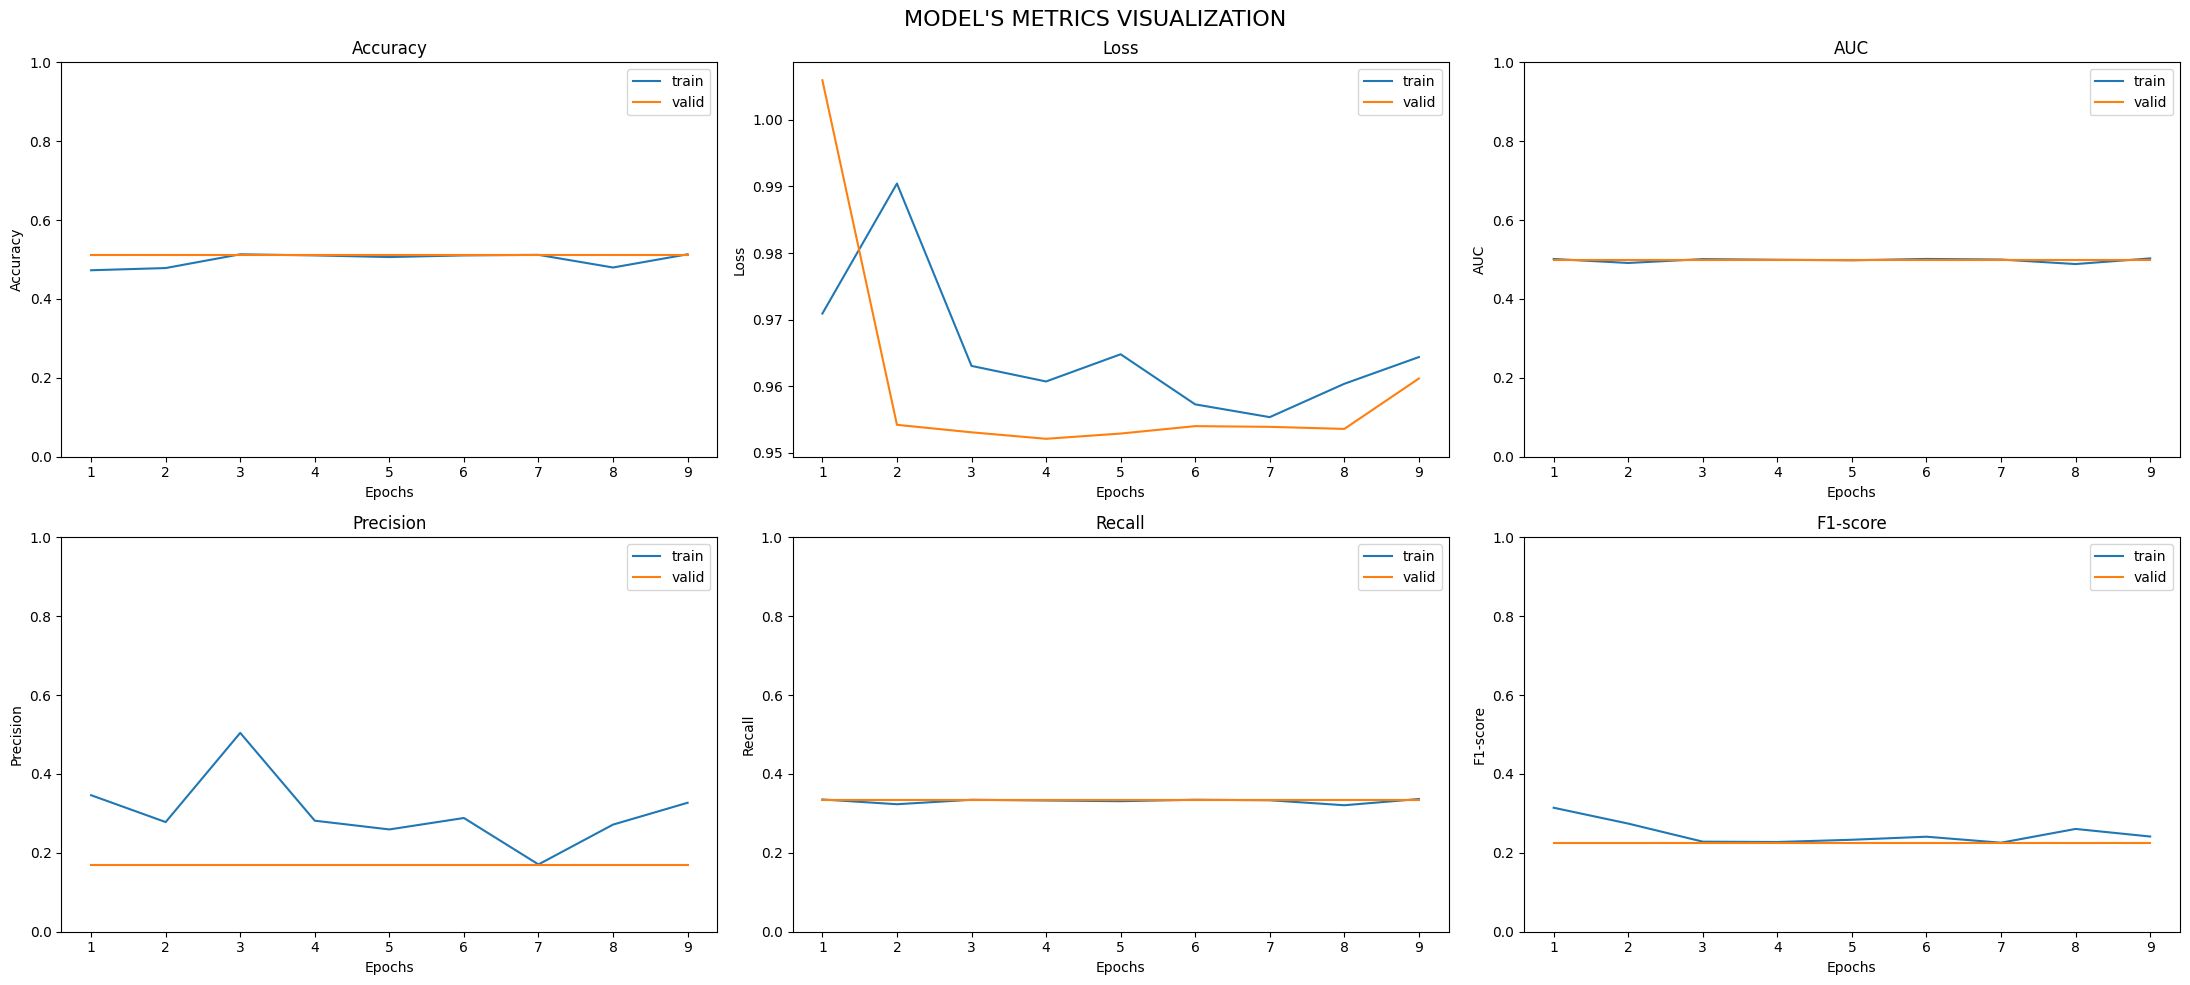

In [11]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    fig.suptitle("MODEL'S METRICS VISUALIZATION", fontsize=16)

    # Accuracy
    axes[0,0].plot(epochs, history["train_acc"], label="train")
    axes[0,0].plot(epochs, history["valid_acc"], label="valid")
    axes[0,0].set_title("Accuracy")
    axes[0,0].set_xlabel("Epochs")
    axes[0,0].set_ylabel("Accuracy")
    axes[0,0].set_ylim([0, 1])
    axes[0,0].legend()

    # Loss
    axes[0,1].plot(epochs, history["train_loss"], label="train")
    axes[0,1].plot(epochs, history["valid_loss"], label="valid")
    axes[0,1].set_title("Loss")
    axes[0,1].set_xlabel("Epochs")
    axes[0,1].set_ylabel("Loss")
    axes[0,1].legend()

    # AUC
    axes[0,2].plot(epochs, history["train_auc"], label="train")
    axes[0,2].plot(epochs, history["valid_auc"], label="valid")
    axes[0,2].set_title("AUC")
    axes[0,2].set_xlabel("Epochs")
    axes[0,2].set_ylabel("AUC")
    axes[0,2].set_ylim([0, 1])
    axes[0,2].legend()

    # Precision
    axes[1,0].plot(epochs, history["train_precision"], label="train")
    axes[1,0].plot(epochs, history["valid_precision"], label="valid")
    axes[1,0].set_title("Precision")
    axes[1,0].set_xlabel("Epochs")
    axes[1,0].set_ylabel("Precision")
    axes[1,0].set_ylim([0, 1])
    axes[1,0].legend()

    # Recall
    axes[1,1].plot(epochs, history["train_recall"], label="train")
    axes[1,1].plot(epochs, history["valid_recall"], label="valid")
    axes[1,1].set_title("Recall")
    axes[1,1].set_xlabel("Epochs")
    axes[1,1].set_ylabel("Recall")
    axes[1,1].set_ylim([0, 1])
    axes[1,1].legend()

    # F1-score
    axes[1,2].plot(epochs, history["train_f1"], label="train")
    axes[1,2].plot(epochs, history["valid_f1"], label="valid")
    axes[1,2].set_title("F1-score")
    axes[1,2].set_xlabel("Epochs")
    axes[1,2].set_ylabel("F1-score")
    axes[1,2].set_ylim([0, 1])
    axes[1,2].legend()

    plt.tight_layout()
    plt.show()
plot_history(history)

In [12]:
def evaluate_model(model, criterion, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    running_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)                     
            loss = criterion(outputs, labels)           
            running_loss += loss.item() * inputs.size(0)

            probs = torch.softmax(outputs, dim=1)       
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())   # store full probability vector

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    avg_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    try:
        auc = roc_auc_score(
            np.eye(len(np.unique(all_labels)))[all_labels],  # one-hot labels
            all_probs, 
            average="macro", 
            multi_class="ovo"
        )
    except:
        auc = 0.0  

    print(f"Test - Loss: {avg_loss:.4f} Acc: {acc:.4f} Prec: {prec:.4f} Rec: {rec:.4f} F1: {f1:.4f} AUC: {auc:.4f}")

    return {"loss": avg_loss, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc}


In [13]:
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

test_metrics = evaluate_model(model, criterion, test_loader, device)


Test - Loss: 0.9582 Acc: 0.5094 Prec: 0.1698 Rec: 0.3333 F1: 0.2250 AUC: 0.6848


In [14]:
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in dataloaders["test"]:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:\n", 
      classification_report(all_labels, all_preds, target_names=class_names, digits=3))



Classification Report:
               precision    recall  f1-score   support

      Bengin      0.000     0.000     0.000        18
   Malignant      0.509     1.000     0.675        81
      Normal      0.000     0.000     0.000        60

    accuracy                          0.509       159
   macro avg      0.170     0.333     0.225       159
weighted avg      0.260     0.509     0.344       159



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


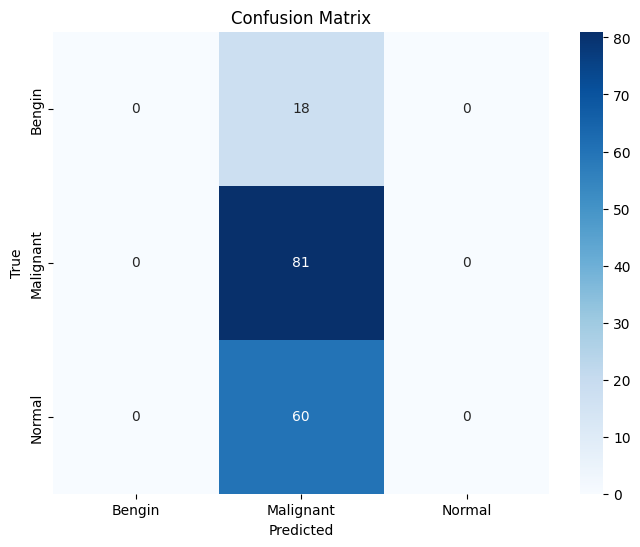

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
